<a href="https://colab.research.google.com/github/jonhnson248/analise-svm-iris/blob/main/classificador_svm_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

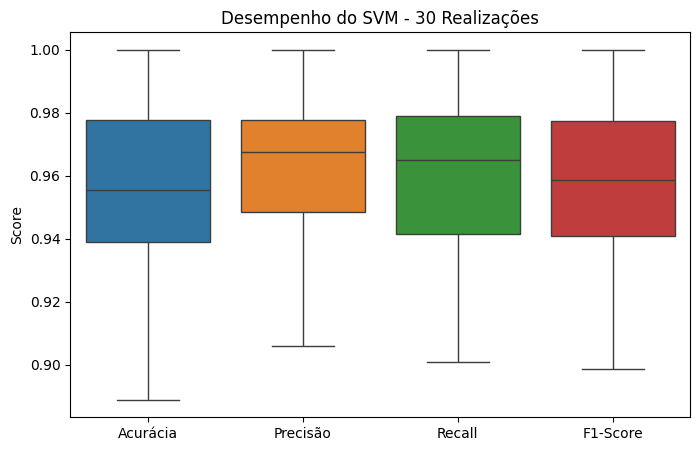

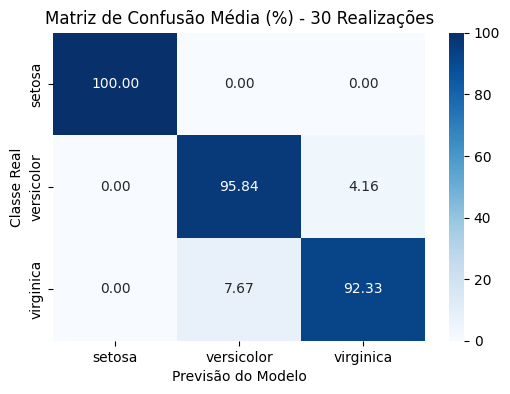

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV

# 1. Carregamento dos dados
iris = load_iris()
X, y = iris.data, iris.target

# 2. Inicialização das estruturas (Antes do Laço)
lista_acuracia, lista_recall, lista_precisao, lista_f1 = [], [], [], []
matriz_acumulada = np.zeros((3, 3))

# 3. Laço das 30 Realizações Independentes
for rodada in range(1, 31):
    # Divisão treino/teste dinâmica usando a rodada como semente
    X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.30, random_state=rodada)

    # Instanciação e treino do SVM
    robo_svm = SVC(random_state=42)
    robo_svm.fit(X_treino, y_treino)

    # Previsões
    previsoes = robo_svm.predict(X_teste)

    # Armazenamento das métricas
    lista_acuracia.append(accuracy_score(y_teste, previsoes))
    lista_precisao.append(precision_score(y_teste, previsoes, average='macro'))
    lista_recall.append(recall_score(y_teste, previsoes, average='macro'))
    lista_f1.append(f1_score(y_teste, previsoes, average='macro'))

    # Acumulação da matriz de confusão
    matriz_acumulada += confusion_matrix(y_teste, previsoes)

# 4. Pós-Processamento da Matriz para Percentual
matriz_percentual = (matriz_acumulada / matriz_acumulada.sum(axis=1, keepdims=True)) * 100

# 5. Visualização com Seaborn (Boxplot)
dados_metricas = {
    'Acurácia': lista_acuracia,
    'Precisão': lista_precisao,
    'Recall': lista_recall,
    'F1-Score': lista_f1
}
df_resultados = pd.DataFrame(dados_metricas)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_resultados)
plt.title("Desempenho do SVM - 30 Realizações")
plt.ylabel("Score")
plt.show()

# 6. Visualização da Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_percentual, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Matriz de Confusão Média (%) - 30 Realizações")
plt.xlabel("Previsão do Modelo")
plt.ylabel("Classe Real")
plt.show()

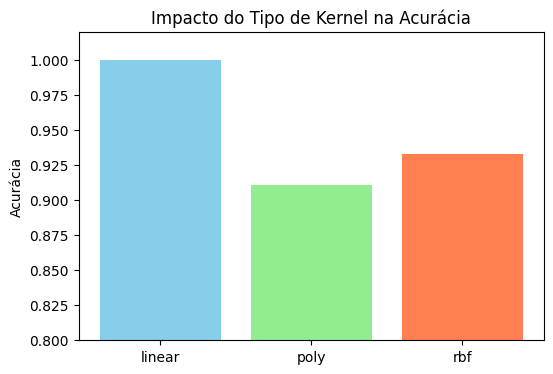

In [6]:
# Exploração no tipo de Kernel

# Lista de kernels e dicionário para salvar os resultados
kernels = ['linear', 'poly', 'rbf']
resultados_kernel = {}

# Laço para testar cada kernel
for k in kernels:
    modelo_kernel = SVC(kernel=k, random_state=42)
    modelo_kernel.fit(X_treino, y_treino)
    previsoes = modelo_kernel.predict(X_teste)

    # Salva a acurácia associada ao nome do kernel
    resultados_kernel[k] = accuracy_score(y_teste, previsoes)

# Gerando o gráfico de barras
plt.figure(figsize=(6, 4))
plt.bar(resultados_kernel.keys(), resultados_kernel.values(), color=['skyblue', 'lightgreen', 'coral'])
plt.title("Impacto do Tipo de Kernel na Acurácia")
plt.ylabel("Acurácia")
plt.ylim(0.8, 1.02)  # Ajuste do limite para visualizar melhor as diferenças
plt.show()

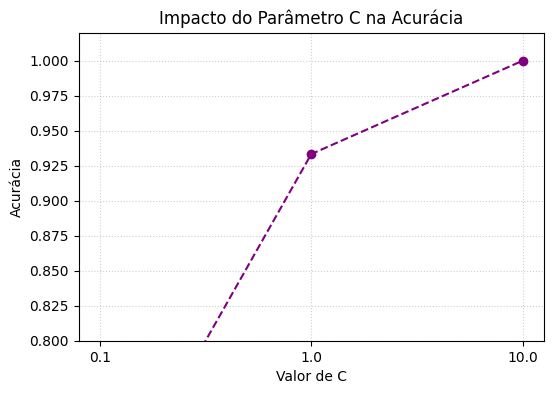

In [7]:
# Exploração no valor de C

# Lista de valores para C e dicionário para os resultados
valores_c = [0.1, 1.0, 10.0]
resultados_c = {}

# Laço para testar cada valor de C
for c in valores_c:
    # Mantemos o kernel rbf fixo para isolar o efeito do C
    modelo_c = SVC(C=c, kernel='rbf', random_state=42)
    modelo_c.fit(X_treino, y_treino)
    previsoes = modelo_c.predict(X_teste)

    # Salva a acurácia convertendo o número para texto para usar como chave
    resultados_c[str(c)] = accuracy_score(y_teste, previsoes)

# Gerando o gráfico de linhas
plt.figure(figsize=(6, 4))
plt.plot(resultados_c.keys(), resultados_c.values(), marker='o', color='purple', linestyle='--')
plt.title("Impacto do Parâmetro C na Acurácia")
plt.xlabel("Valor de C")
plt.ylabel("Acurácia")
plt.ylim(0.8, 1.02)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

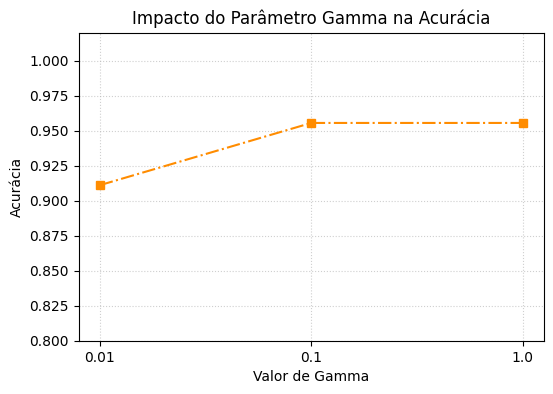

In [8]:
# Exploração no valor de Gamma

# Lista de valores para Gamma e dicionário para os resultados
valores_gamma = [0.01, 0.1, 1.0]
resultados_gamma = {}

# Laço para testar cada valor de Gamma
for g in valores_gamma:
    # Mantemos o kernel RBF e o C=1.0 fixos para isolar o Gamma
    modelo_gamma = SVC(gamma=g, C=1.0, kernel='rbf', random_state=42)
    modelo_gamma.fit(X_treino, y_treino)
    previsoes = modelo_gamma.predict(X_teste)

    # Salva a acurácia convertendo o número para texto
    resultados_gamma[str(g)] = accuracy_score(y_teste, previsoes)

# Gerando o gráfico de linhas para o Gamma
plt.figure(figsize=(6, 4))
plt.plot(resultados_gamma.keys(), resultados_gamma.values(), marker='s', color='darkorange', linestyle='-.')
plt.title("Impacto do Parâmetro Gamma na Acurácia")
plt.xlabel("Valor de Gamma")
plt.ylabel("Acurácia")
plt.ylim(0.8, 1.02)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

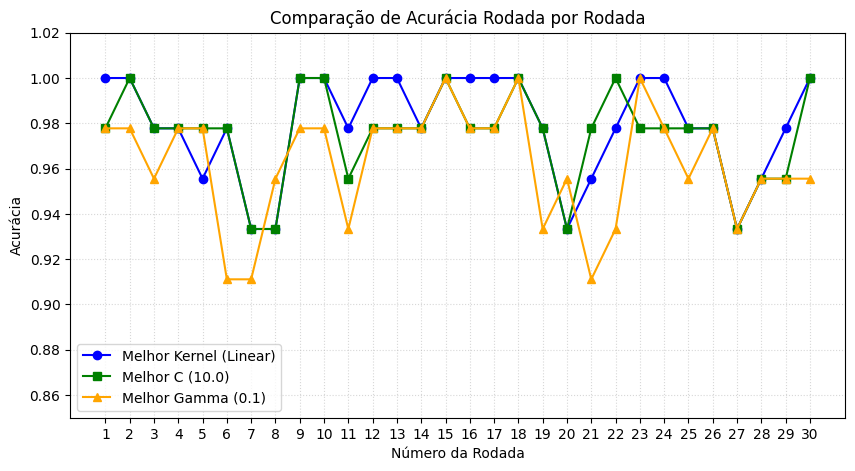

In [10]:
# Comparação Direta dos Vencedores em 30 Rodadas

# Listas para guardar as acurácias de cada modelo campeão
acc_kernel_linear = []
acc_c_10 = []
acc_gamma_01 = []

# Laço das 30 realizações independentes (mesmo sorteio para todos)
for rodada in range(1, 31):
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.30, random_state=rodada
    )

    # 1. Testando o Kernel vencedor (Linear)
    mdl_linear = SVC(kernel='linear', random_state=42)
    mdl_linear.fit(X_treino, y_treino)
    acc_kernel_linear.append(accuracy_score(y_teste, mdl_linear.predict(X_teste)))

    # 2. Testando o C vencedor (10.0)
    mdl_c10 = SVC(C=10.0, kernel='rbf', random_state=42)
    mdl_c10.fit(X_treino, y_treino)
    acc_c_10.append(accuracy_score(y_teste, mdl_c10.predict(X_teste)))

    # 3. Testando o Gamma vencedor (0.1)
    mdl_g01 = SVC(gamma=0.1, kernel='rbf', random_state=42)
    mdl_g01.fit(X_treino, y_treino)
    acc_gamma_01.append(accuracy_score(y_teste, mdl_g01.predict(X_teste)))

# Criando o gráfico de linhas comparativo
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, 31),
    acc_kernel_linear,
    label='Melhor Kernel (Linear)',
    marker='o',
    color='blue',
)
plt.plot(
    range(1, 31), acc_c_10, label='Melhor C (10.0)', marker='s', color='green'
)
plt.plot(
    range(1, 31),
    acc_gamma_01,
    label='Melhor Gamma (0.1)',
    marker='^',
    color='orange',
)

plt.title('Comparação de Acurácia Rodada por Rodada')
plt.xlabel('Número da Rodada')
plt.ylabel('Acurácia')
plt.xticks(range(1, 31))
plt.ylim(0.85, 1.02)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()